# Reproduce Results

This notebook regenerates all key figures and metrics from the report without any retraining. It assumes the following checkpoints exist in `../checkpoints/`:

- `scaler.pkl`
- `feature_cols.pkl`
- `lstm_best.pt`
- `tcn_best.pt`
- `patchtst_best.pt`

Runtime: under 2 minutes on CPU.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split

RUL_CLIP    = 125
WINDOW_SIZE = 30
col_names   = ['unit', 'cycle', 'os1', 'os2', 'os3'] + [f's{i}' for i in range(1, 22)]
device      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

with open('../checkpoints/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)
with open('../checkpoints/feature_cols.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

print("checkpoints loaded. running on:", device)

checkpoints loaded. running on: cpu


#### Model Definitions

In [2]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.head = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(hidden_size, 32),
            nn.ReLU(), nn.Linear(32, 1)
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).squeeze(-1).clamp(min=0)


class CausalConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout):
        super().__init__()
        self.pad   = (kernel_size - 1) * dilation
        self.conv1 = nn.utils.weight_norm(
            nn.Conv1d(in_channels, out_channels, kernel_size, dilation=dilation, padding=self.pad))
        self.conv2 = nn.utils.weight_norm(
            nn.Conv1d(out_channels, out_channels, kernel_size, dilation=dilation, padding=self.pad))
        self.relu     = nn.ReLU()
        self.dropout  = nn.Dropout(dropout)
        self.residual = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()
    def forward(self, x):
        out = self.dropout(self.relu(self.conv1(x)[:, :, :-self.pad]))
        out = self.dropout(self.relu(self.conv2(out)[:, :, :-self.pad]))
        return self.relu(out + self.residual(x))

class TCNModel(nn.Module):
    def __init__(self, input_size, num_channels, kernel_size, dropout):
        super().__init__()
        layers, in_ch = [], input_size
        for i, out_ch in enumerate(num_channels):
            layers.append(CausalConvBlock(in_ch, out_ch, kernel_size, 2**i, dropout))
            in_ch = out_ch
        self.network = nn.Sequential(*layers)
        self.head = nn.Sequential(nn.Linear(num_channels[-1], 32), nn.ReLU(), nn.Linear(32, 1))
    def forward(self, x):
        out = self.network(x.permute(0, 2, 1))
        return self.head(out[:, :, -1]).squeeze(-1).clamp(min=0)


class PatchTST(nn.Module):
    def __init__(self, seq_len, input_size, patch_size, d_model, nhead, num_layers, dropout):
        super().__init__()
        self.patch_size  = patch_size
        self.num_patches = seq_len // patch_size
        self.patch_embed = nn.Linear(patch_size * input_size, d_model)
        self.pos_embed   = nn.Parameter(torch.zeros(1, self.num_patches, d_model))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
                            dim_feedforward=d_model*4, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(self.num_patches * d_model, 64), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(64, 1)
        )
    def forward(self, x):
        B, T, C = x.shape
        x = x.reshape(B, self.num_patches, self.patch_size * C)
        x = self.dropout(self.patch_embed(x) + self.pos_embed)
        x = self.transformer(x)
        return self.head(x.reshape(B, -1)).squeeze(-1).clamp(min=0)

#### Load all checkpoints

In [3]:
lstm_model = LSTMModel(len(feature_cols), hidden_size=128, num_layers=2, dropout=0.2)
lstm_model.load_state_dict(torch.load('../checkpoints/lstm_best.pt', map_location=device))
lstm_model.to(device).eval()

tcn_model = TCNModel(len(feature_cols), num_channels=[64,64,64,64], kernel_size=3, dropout=0.1)
tcn_model.load_state_dict(torch.load('../checkpoints/tcn_best.pt', map_location=device))
tcn_model.to(device).eval()

patchtst_model = PatchTST(seq_len=WINDOW_SIZE, input_size=len(feature_cols), patch_size=5,
                           d_model=64, nhead=4, num_layers=2, dropout=0.1)
patchtst_model.load_state_dict(torch.load('../checkpoints/patchtst_best.pt', map_location=device))
patchtst_model.to(device).eval()

print("lstm      :", sum(p.numel() for p in lstm_model.parameters()), "parameters")
print("tcn       :", sum(p.numel() for p in tcn_model.parameters()), "parameters")
print("patchtst  :", sum(p.numel() for p in patchtst_model.parameters()), "parameters")

lstm      : 209985 parameters
tcn       : 92801 parameters
patchtst  : 129601 parameters


/Users/anjanaramachandran/.thesis/env/venv/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


#### Shared utilities and test data

In [4]:
def add_rul(df):
    max_cycles = df.groupby('unit')['cycle'].max()
    df = df.merge(max_cycles.rename('max_cycle'), on='unit')
    df['rul'] = (df['max_cycle'] - df['cycle']).clip(upper=RUL_CLIP)
    return df

def make_test_windows(df, feature_cols, window_size):
    X = []
    for unit_id, group in df.groupby('unit'):
        feats = group[feature_cols].values
        if len(feats) >= window_size:
            X.append(feats[-window_size:])
        else:
            pad = np.zeros((window_size - len(feats), len(feature_cols)))
            X.append(np.vstack([pad, feats]))
    return np.array(X, dtype=np.float32)

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def phm_score(y_true, y_pred):
    ### Ref---> https://doi.org/10.1016/j.ress.2017.11.021
    d = y_pred - y_true
    s = np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)
    return np.sum(s)

def predict(model, X):
    with torch.no_grad():
        return model(torch.tensor(X).to(device)).cpu().numpy()

### load FD001 test set
test_raw = pd.read_csv('../data/raw/test_FD001.txt', sep='\s+', header=None, names=col_names)
rul_test = pd.read_csv('../data/raw/RUL_FD001.txt',  header=None, names=['rul'])

test_df  = test_raw.copy()
test_df[feature_cols] = scaler.transform(test_df[feature_cols])

X_test = make_test_windows(test_df, feature_cols, WINDOW_SIZE)
y_test = rul_test['rul'].values.astype(np.float32)

preds_lstm = predict(lstm_model,     X_test)
preds_tcn  = predict(tcn_model,      X_test)
preds_ptst = predict(patchtst_model, X_test)

print("FD001 test predictions ready.")

FD001 test predictions ready.


#### Figure 1: predicted vs true RUL for all three models

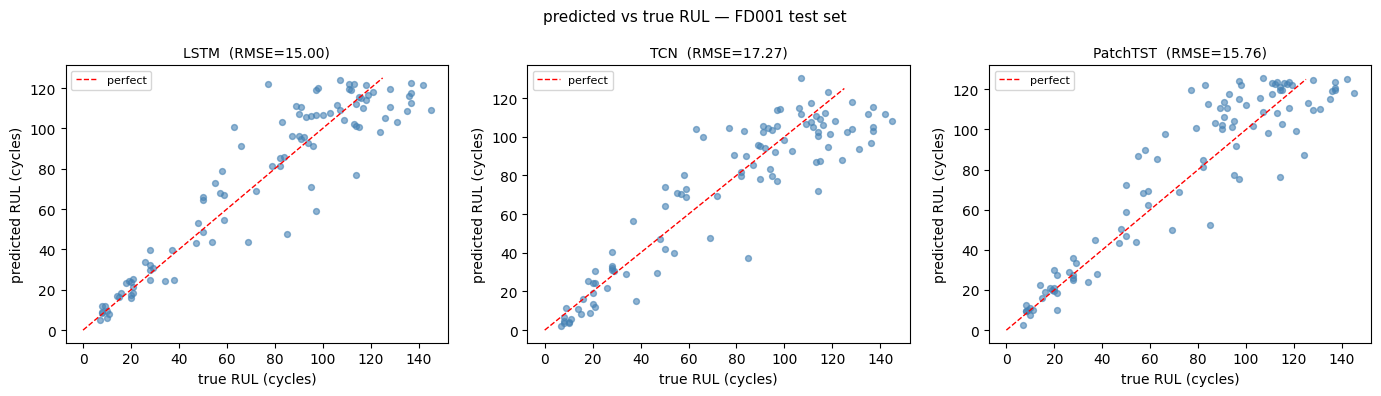

saved fig1_scatter.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
models_preds = [('LSTM', preds_lstm), ('TCN', preds_tcn), ('PatchTST', preds_ptst)]

for ax, (name, preds) in zip(axes, models_preds):
    ax.scatter(y_test, preds, alpha=0.6, s=18, color='steelblue')
    ax.plot([0, 125], [0, 125], 'r--', linewidth=1, label='perfect')
    r = rmse(y_test, preds)
    ax.set_title(f'{name}  (RMSE={r:.2f})', fontsize=10)
    ax.set_xlabel('true RUL (cycles)')
    ax.set_ylabel('predicted RUL (cycles)')
    ax.legend(fontsize=8)

plt.suptitle('predicted vs true RUL — FD001 test set', fontsize=11)
plt.tight_layout()
plt.savefig('../checkpoints/fig1_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved fig1_scatter.png")

#### Figure 2: cross-dataset RMSE bar chart

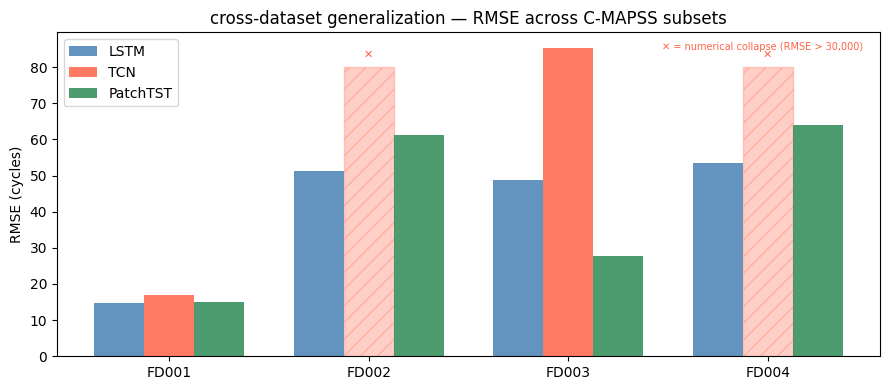

saved fig2_cross_dataset.png


In [6]:
subsets = ['FD001', 'FD002', 'FD003', 'FD004']

rmse_results = {
    'LSTM':     [14.819, 51.312, 48.748, 53.439],
    'TCN':      [16.930, None,   85.348, None],
    'PatchTST': [15.090, 61.201, 27.817, 63.944]
}

colors = {'LSTM': 'steelblue', 'TCN': 'tomato', 'PatchTST': 'seagreen'}
x     = np.arange(4)
width = 0.25

fig, ax = plt.subplots(figsize=(9, 4))

for j, (name, vals) in enumerate(rmse_results.items()):
    for i, v in enumerate(vals):
        xpos = x[i] + (j - 1) * width
        if v is None:
            ax.bar(xpos, 80, width=width, color=colors[name], alpha=0.3,
                   hatch='//', edgecolor=colors[name])
            ax.text(xpos, 82, '✕', ha='center', va='bottom',
                    fontsize=8, color=colors[name])
        else:
            ax.bar(xpos, v, width=width, color=colors[name],
                   alpha=0.85, label=name if i == 0 else '')

ax.set_xticks(x)
ax.set_xticklabels(subsets)
ax.set_ylabel('RMSE (cycles)')
ax.set_title('cross-dataset generalization — RMSE across C-MAPSS subsets')
ax.legend()
ax.text(0.98, 0.97, '✕ = numerical collapse (RMSE > 30,000)',
        transform=ax.transAxes, ha='right', va='top', fontsize=7, color='tomato')

plt.tight_layout()
plt.savefig('../checkpoints/fig2_cross_dataset.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved fig2_cross_dataset.png")

#### Final Results Table

In [7]:
print("=" * 52)
print("Table 1 — FD001 test set results")
print("=" * 52)
print(f"{'Model':<12} {'RMSE':>8} {'PHM score':>12} {'Params':>10}")
print("-" * 52)
for name, preds in models_preds:
    r = rmse(y_test, preds)
    p = phm_score(y_test, preds)
    params = sum(par.numel() for par in
                 (lstm_model if name == 'LSTM' else
                  tcn_model  if name == 'TCN'  else patchtst_model).parameters())
    print(f"{name:<12} {r:>8.3f} {p:>12.1f} {params:>10,}")

print()
print("=" * 52)
print("Table 2 — Cross-dataset RMSE")
print("=" * 52)
print(f"{'Subset':<8} {'LSTM':>10} {'TCN':>10} {'PatchTST':>10}")
print("-" * 42)
rows = [
    ('FD001', 14.819, 16.930, 15.090),
    ('FD002', 51.312, None,   61.201),
    ('FD003', 48.748, 85.348, 27.817),
    ('FD004', 53.439, None,   63.944),
]
for subset, l, t, p in rows:
    t_str = 'collapsed' if t is None else f'{t:.3f}'
    print(f"{subset:<8} {l:>10.3f} {t_str:>10} {p:>10.3f}")

Table 1 — FD001 test set results
Model            RMSE    PHM score     Params
----------------------------------------------------
LSTM           15.003        377.4    209,985
TCN            17.266        436.5     92,801
PatchTST       15.759        446.7    129,601

Table 2 — Cross-dataset RMSE
Subset         LSTM        TCN   PatchTST
------------------------------------------
FD001        14.819     16.930     15.090
FD002        51.312  collapsed     61.201
FD003        48.748     85.348     27.817
FD004        53.439  collapsed     63.944
